In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timezone, timedelta
from dataclasses import asdict

from data_generator.server_simulator import ServerSimulator
from data_generator.ups_inverter_simulator import UPSSimulator, InverterSimulator

sns.set_theme(style='darkgrid')
%matplotlib inline
print('OK')

OK


In [8]:
srv_sim = ServerSimulator(num_servers=100, num_racks=10, fault_probability=0.01, random_seed=42)
ups_sim = UPSSimulator(num_ups=4)
inv_sim = InverterSimulator(num_inverters=4, islanding_probability=0.02)

start_time = datetime(2024, 6, 15, 0, 0, tzinfo=timezone.utc)
interval   = timedelta(minutes=5)

server_records, ups_records, inv_records = [], [], []

for i in range(288):  # 24h * 12 snapshots/hora
    ts = start_time + interval * i
    server_records.extend([asdict(r) for r in srv_sim.generate_snapshot(ts)])
    ups_records.extend([asdict(r)    for r in ups_sim.generate_snapshot(ts)])
    inv_records.extend([asdict(r)    for r in inv_sim.generate_snapshot(ts)])

df_srv = pd.DataFrame(server_records)
df_ups = pd.DataFrame(ups_records)
df_inv = pd.DataFrame(inv_records)

df_srv['timestamp_utc'] = pd.to_datetime(df_srv['timestamp_utc'], utc=True)
df_ups['timestamp_utc'] = pd.to_datetime(df_ups['timestamp_utc'], utc=True)
df_inv['timestamp_utc'] = pd.to_datetime(df_inv['timestamp_utc'], utc=True)
df_srv['hour'] = df_srv['timestamp_utc'].dt.hour

print(f'Servidores: {len(df_srv):,} | UPS: {len(df_ups):,} | Inversores: {len(df_inv):,}')
df_srv.head(3)

2026-03-02 19:59:37.440 | INFO     | data_generator.server_simulator:__init__:91 - ServerSimulator initialized: 100 servers across 10 racks in ZONE-A
2026-03-02 19:59:37.442 | INFO     | data_generator.ups_inverter_simulator:__init__:110 - UPSSimulator: 4 units in ZONE-A
2026-03-02 19:59:37.443 | INFO     | data_generator.ups_inverter_simulator:__init__:222 - InverterSimulator: 4 inverters in ZONE-A


Servidores: 28,800 | UPS: 1,152 | Inversores: 1,152


,event_id,server_id,rack_id,datacenter_zone,server_profile,timestamp_utc,power_draw_w,cpu_power_w,ram_power_w,idle_power_w,...,outlet_temp_c,cpu_utilization,memory_utilization,disk_io_utilization,network_utilization,pue_contribution,cooling_state,fan_speed_rpm,is_anomaly,hour
0,4459aa3a-073e-41d8-9887-c141effb73f6,SRV-287192E1,RACK-01,ZONE-A,compute,2024-06-15 00:00:00+00:00,339.62,201.62,48.0,90.0,...,25.01,0.8065,0.7239,0.3237,0.1621,1.0019,elevated,3709,False,0
1,09e28ab9-e08c-494d-9619-9b0853bbe519,SRV-0772E787,RACK-02,ZONE-A,storage,2024-06-15 00:00:00+00:00,94.34,34.34,24.0,36.0,...,22.76,0.4293,0.5967,0.0876,0.0181,1.0013,normal,1972,False,0
2,19b6519e-9aee-4b34-ac44-b05c72989d02,SRV-EF3DCB6F,RACK-03,ZONE-A,network,2024-06-15 00:00:00+00:00,65.54,29.54,12.0,24.0,...,23.44,0.6564,0.6655,0.0361,0.2276,1.0027,normal,2381,False,0


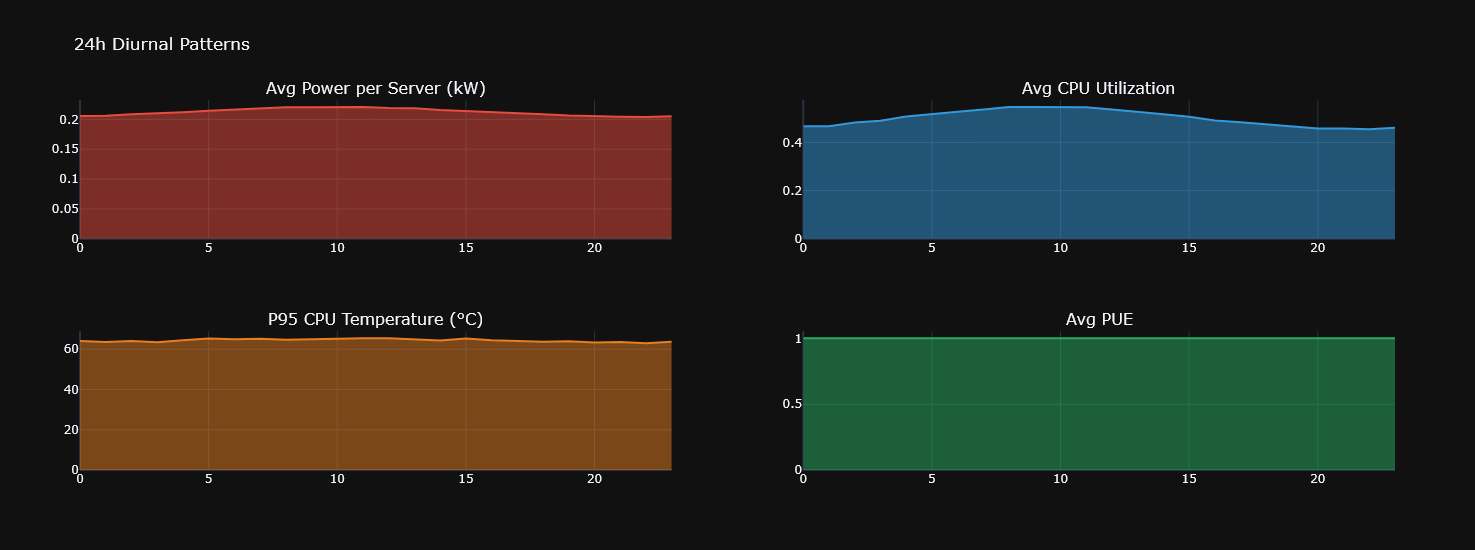

In [9]:
hourly = df_srv.groupby('hour').agg(
    avg_power_kw = ('power_draw_w', lambda x: x.mean()/1000),
    avg_cpu_util = ('cpu_utilization', 'mean'),
    p95_cpu_temp = ('cpu_temp_c', lambda x: x.quantile(0.95)),
    avg_pue      = ('pue_contribution', 'mean'),
).reset_index()

fig = make_subplots(rows=2, cols=2, subplot_titles=[
    'Avg Power per Server (kW)', 'Avg CPU Utilization',
    'P95 CPU Temperature (°C)',  'Avg PUE'
])
fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['avg_power_kw'],  fill='tozeroy', line=dict(color='#e74c3c')), row=1, col=1)
fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['avg_cpu_util'],  fill='tozeroy', line=dict(color='#3498db')), row=1, col=2)
fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['p95_cpu_temp'],  fill='tozeroy', line=dict(color='#e67e22')), row=2, col=1)
fig.add_trace(go.Scatter(x=hourly['hour'], y=hourly['avg_pue'],       fill='tozeroy', line=dict(color='#27ae60')), row=2, col=2)
fig.update_layout(height=550, title='24h Diurnal Patterns', showlegend=False, template='plotly_dark')
fig.show()

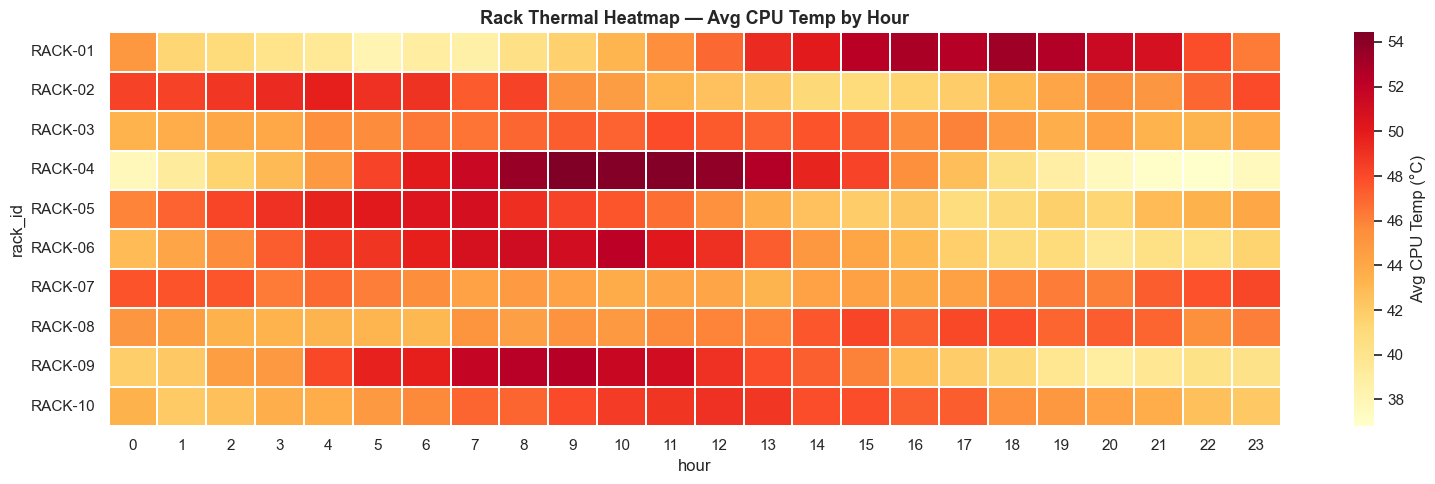

In [10]:
rack_pivot = df_srv.groupby(['rack_id','hour'])['cpu_temp_c'].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(rack_pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Avg CPU Temp (°C)'})
ax.set_title('Rack Thermal Heatmap — Avg CPU Temp by Hour', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rack_thermal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

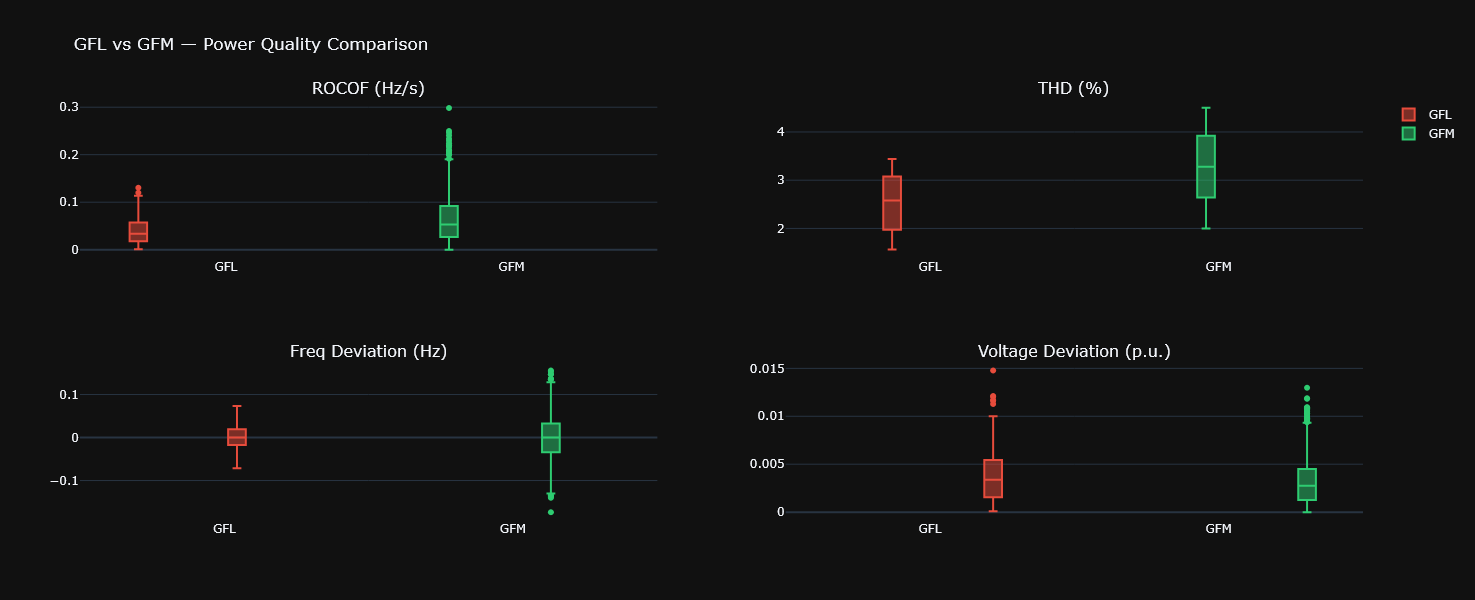

              rocof_hz_per_s  thd_percent  freq_deviation_hz
control_mode                                                
GFL                   0.0406       2.5494             0.0009
GFM                   0.0638       3.2630             0.0000


In [11]:
df_gfx = df_inv[df_inv['control_mode'].isin(['GFL','GFM'])].copy()

fig = make_subplots(rows=2, cols=2, subplot_titles=[
    'ROCOF (Hz/s)', 'THD (%)',
    'Freq Deviation (Hz)', 'Voltage Deviation (p.u.)'
])
metrics = [('rocof_hz_per_s',1,1),('thd_percent',1,2),
           ('freq_deviation_hz',2,1),('voltage_deviation_pu',2,2)]
colors  = {'GFL':'#e74c3c','GFM':'#2ecc71'}

for metric, row, col in metrics:
    for mode in ['GFL','GFM']:
        fig.add_trace(go.Box(
            y=df_gfx[df_gfx['control_mode']==mode][metric],
            name=mode, marker_color=colors[mode],
            showlegend=(row==1 and col==1)
        ), row=row, col=col)

fig.update_layout(height=600, title='GFL vs GFM — Power Quality Comparison',
                  template='plotly_dark', boxmode='group')
fig.show()

# Tabela estatística
print(df_gfx.groupby('control_mode')[['rocof_hz_per_s','thd_percent','freq_deviation_hz']].mean().round(4))

In [12]:
print('=' * 50)
print('KEY INSIGHTS')
print('=' * 50)
print(f"Avg power/server : {df_srv['power_draw_w'].mean():.1f} W")
print(f"Avg PUE          : {df_srv['pue_contribution'].mean():.3f}")
print(f"Anomaly rate     : {df_srv['is_anomaly'].mean():.2%}")
for mode in ['GFL','GFM']:
    sub = df_gfx[df_gfx['control_mode']==mode]
    print(f"{mode} avg ROCOF  : {sub['rocof_hz_per_s'].mean():.4f} Hz/s")
    print(f"{mode} avg THD    : {sub['thd_percent'].mean():.2f}%")

KEY INSIGHTS
Avg power/server : 212.4 W
Avg PUE          : 1.002
Anomaly rate     : 1.06%
GFL avg ROCOF  : 0.0406 Hz/s
GFL avg THD    : 2.55%
GFM avg ROCOF  : 0.0638 Hz/s
GFM avg THD    : 3.26%
